In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

print("SVM Fake News Detector - Simple Model")
print("="*60)

SVM Fake News Detector - Simple Model


In [2]:
DATA_PATH = "../data/raw/multinli_1.0/multinli_1.0_train.jsonl"

data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item["gold_label"] != "-":
            data.append(item)

data = data[:4000]

df = pd.DataFrame(data)[["sentence1", "sentence2", "gold_label"]]

print(f"Dataset: {len(df)} samples")
print("\nLabel distribution:")
print(df["gold_label"].value_counts())

Dataset: 4000 samples

Label distribution:
gold_label
contradiction    1469
entailment       1371
neutral          1160
Name: count, dtype: int64


In [3]:
label_mapping = {"entailment": 0, "neutral": 1, "contradiction": 2}

sentence1_texts = df["sentence1"].values
sentence2_texts = df["sentence2"].values
labels = df["gold_label"].map(label_mapping).values

print(f"Sentence1 shape: {sentence1_texts.shape}")
print(f"Sentence2 shape: {sentence2_texts.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nExample sentence1:\n{sentence1_texts[0][:100]}...")
print(f"Example sentence2:\n{sentence2_texts[0][:100]}...")

Sentence1 shape: (4000,)
Sentence2 shape: (4000,)
Labels shape: (4000,)

Example sentence1:
Conceptually cream skimming has two basic dimensions - product and geography....
Example sentence2:
Product and geography are what make cream skimming work. ...


In [ ]:
print("Vectorizing sentence1 and sentence2 with TF-IDF...")
vectorizer1 = TfidfVectorizer(max_features=5000, max_df=0.95, min_df=2, ngram_range=(1, 2))
vectorizer2 = TfidfVectorizer(max_features=5000, max_df=0.95, min_df=2, ngram_range=(1, 2))

X1 = vectorizer1.fit_transform(sentence1_texts)
X2 = vectorizer2.fit_transform(sentence2_texts)

# Combine features (e.g., horizontally)
from scipy.sparse import hstack
X = hstack([X1, X2])
print(f"✓ Combined vectorized shape: {X.shape}")

Vectorizing texts with TF-IDF...


NameError: name 'texts' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Train samples: 3200
Test samples: 800
Features: 60000


In [ ]:
print("Training SVM classifier...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("✓ Training complete")

Training SVM classifier (linear kernel) with wider C search...


In [ ]:
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
target_names = ["Entailment (VRAI)", "Neutral (À_VÉRIFIER)", "Contradiction (FAUX)"]
print(classification_report(y_test, y_pred, target_names=target_names))

Test Accuracy: 0.4462
Cohen's Kappa: 0.1682

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

   Entailment (VRAI)       0.41      0.44      0.43       274
Neutral (À_VÉRIFIER)       0.38      0.40      0.39       232
Contradiction (FAUX)       0.56      0.49      0.52       294

            accuracy                           0.45       800
           macro avg       0.45      0.44      0.44       800
        weighted avg       0.45      0.45      0.45       800



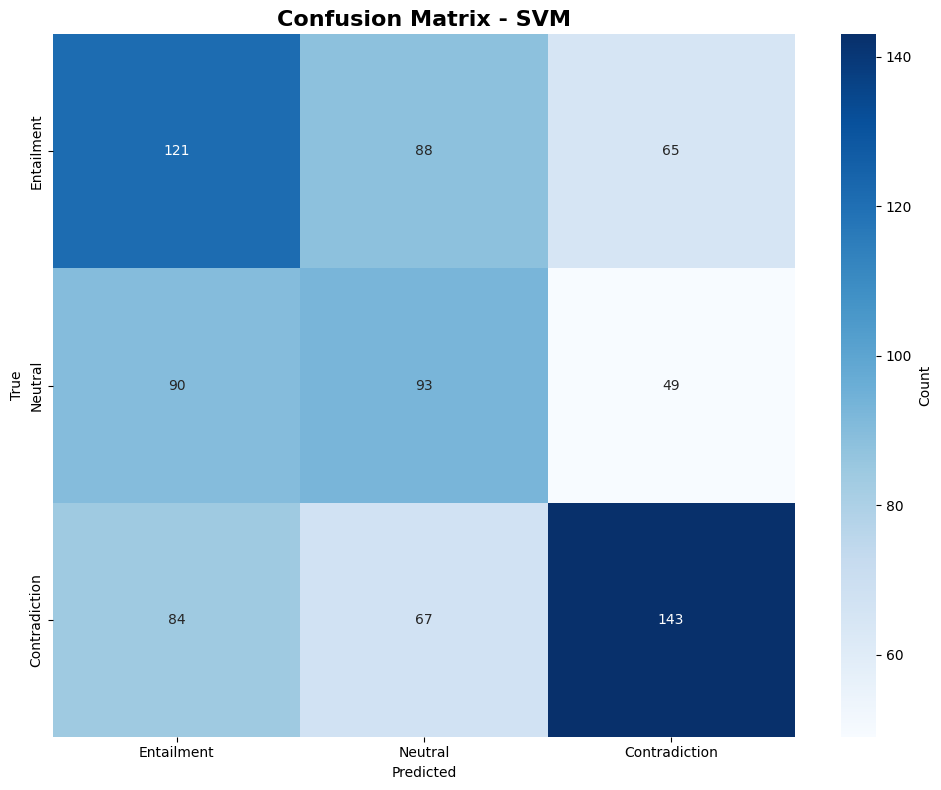

Entailment: 0.4416
Neutral: 0.4009
Contradiction: 0.4864


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Entailment", "Neutral", "Contradiction"],
    yticklabels=["Entailment", "Neutral", "Contradiction"],
    cbar_kws={"label": "Count"}
)
plt.title("Confusion Matrix - SVM", fontsize=16, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

for i, label in enumerate(["Entailment", "Neutral", "Contradiction"]):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"{label}: {class_acc:.4f}")

In [ ]:
def predict_claim_svm(sentence1, sentence2, threshold=0.6):
    X1_input = vectorizer1.transform([sentence1])
    X2_input = vectorizer2.transform([sentence2])
    X_char_input = char_vectorizer.transform([sentence1 + " [SEP] " + sentence2])
    X_input = hstack([X1_input, X2_input, X_char_input])
    
    proba = svm_model.predict_proba(X_input)[0]
    pred_class = np.argmax(proba)
    confidence = proba[pred_class]
    
    label_map = {0: "entailment", 1: "neutral", 2: "contradiction"}
    decision_map = {0: "VRAI", 1: "À_VÉRIFIER", 2: "FAUX"}
    
    label = label_map[pred_class]
    
    if (pred_class == 0 or pred_class == 2) and confidence >= threshold:
        decision = decision_map[pred_class]
    else:
        decision = "À_VÉRIFIER"
    
    return decision, label, confidence, proba

print("✓ SVM prediction function ready")

✓ SVM prediction function ready


In [ ]:
test_cases = [
    ("The cat is on the couch.", "An animal is on furniture."),
    ("Python is a programming language.", "Python is a reptile."),
    ("The company made record profits.", "The company is losing money."),
    ("Scientists found a new planet.", "Astronomers discovered a celestial body."),
    ("Water boils at 100 Celsius.", "Water freezes at high temperatures.")
]

print("="*80)
print("SVM PREDICTIONS")
print("="*80)

for i, (s1, s2) in enumerate(test_cases, 1):
    decision, label, confidence, proba = predict_claim_svm(s1, s2, threshold=0.6)
    print(f"\nTest {i}:")
    print(f"  Premise: {s1}")
    print(f"  Claim:   {s2}")
    print(f"  Decision: {decision} (confidence: {confidence:.3f})")
    print(f"  Proba: [E:{proba[0]:.3f} | N:{proba[1]:.3f} | C:{proba[2]:.3f}]")
    print("-" * 80)

SVM PREDICTIONS

Test 1:
  Premise: The cat is on the couch.
  Claim:   An animal is on furniture.
  Decision: À_VÉRIFIER (confidence: 0.453)
  Proba: [E:0.346 | N:0.201 | C:0.453]
--------------------------------------------------------------------------------

Test 2:
  Premise: Python is a programming language.
  Claim:   Python is a reptile.
  Decision: À_VÉRIFIER (confidence: 0.449)
  Proba: [E:0.294 | N:0.449 | C:0.257]
--------------------------------------------------------------------------------

Test 3:
  Premise: The company made record profits.
  Claim:   The company is losing money.
  Decision: À_VÉRIFIER (confidence: 0.464)
  Proba: [E:0.341 | N:0.195 | C:0.464]
--------------------------------------------------------------------------------

Test 4:
  Premise: Scientists found a new planet.
  Claim:   Astronomers discovered a celestial body.
  Decision: À_VÉRIFIER (confidence: 0.529)
  Proba: [E:0.529 | N:0.192 | C:0.280]
------------------------------------------------

In [ ]:
s1 = "Artificial intelligence is transforming technology."
s2 = "AI is changing the tech industry."

decision, label, confidence, proba = predict_claim_svm(s1, s2, threshold=0.5)

print("="*80)
print("CUSTOM SVM PREDICTION")
print("="*80)
print(f"\nPremise: {s1}")
print(f"Claim:   {s2}")
print(f"\nDecision: {decision}")
print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
print(f"\nProbabilities:")
print(f"  Entailment (VRAI):     {proba[0]:.4f}")
print(f"  Neutral (À_VÉRIFIER):  {proba[1]:.4f}")
print(f"  Contradiction (FAUX):  {proba[2]:.4f}")
print("="*80)

CUSTOM SVM PREDICTION

Premise: Artificial intelligence is transforming technology.
Claim:   AI is changing the tech industry.

Decision: À_VÉRIFIER
Confidence: 0.3596 (35.96%)

Probabilities:
  Entailment (VRAI):     0.3188
  Neutral (À_VÉRIFIER):  0.3596
  Contradiction (FAUX):  0.3216
